In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing

california_housing = fetch_california_housing ()
df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
df['Target'] = california_housing.target
df.head()

C:\Users\vivek\anaconda4\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
df.shape

(20640, 9)

In [3]:
print(df.columns)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Target'],
      dtype='object')


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


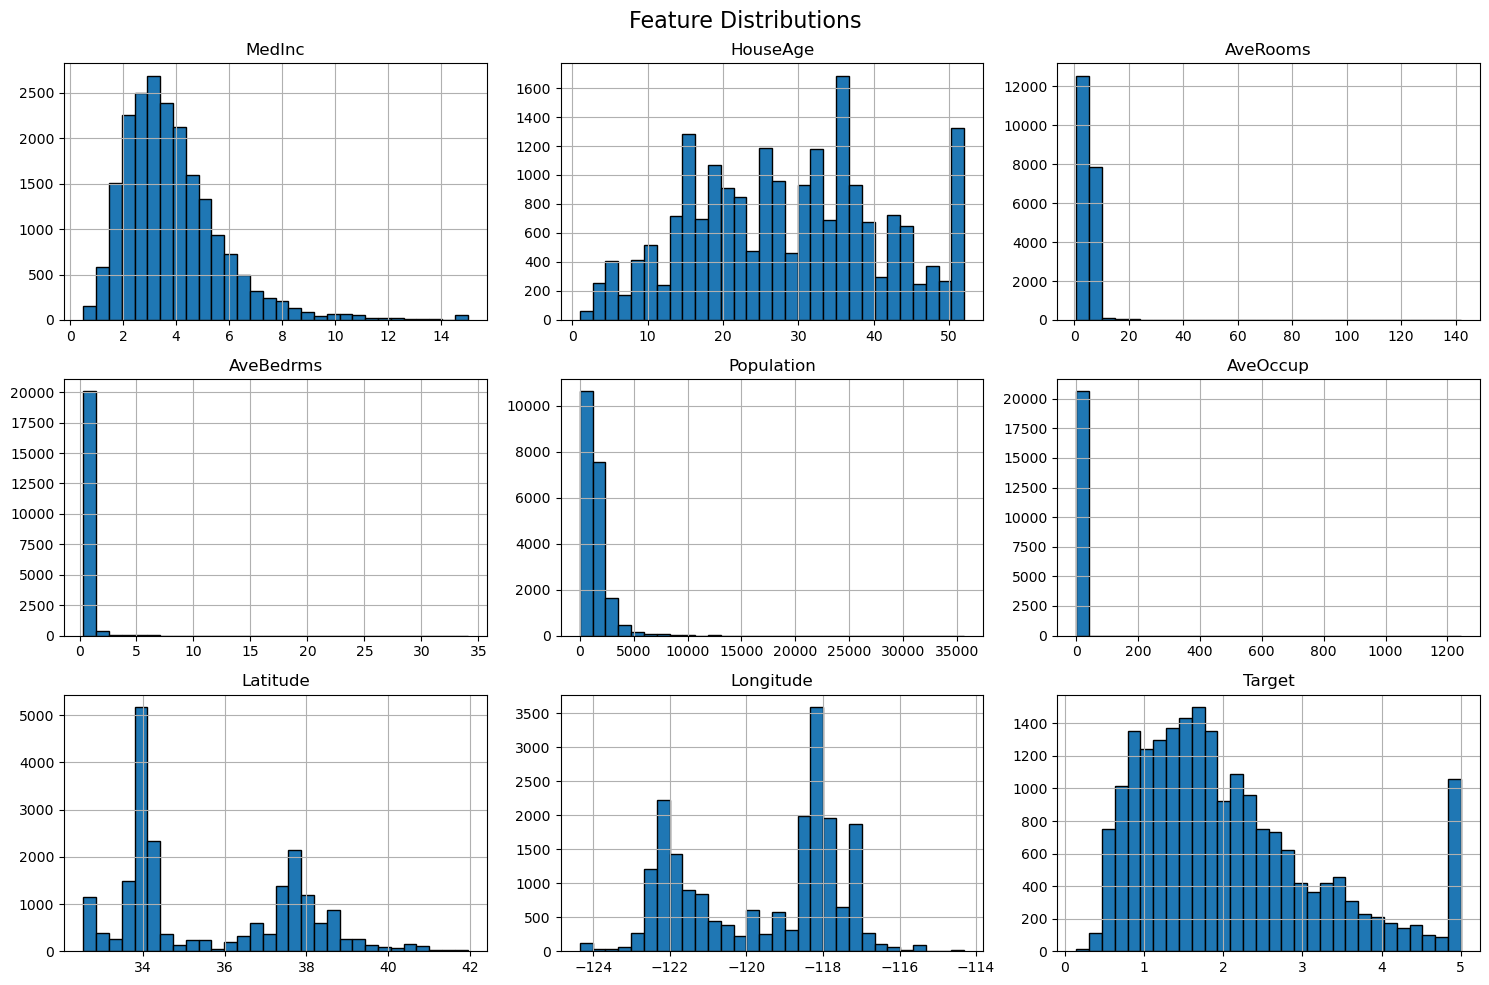

In [5]:
import matplotlib.pyplot as plt 
import seaborn as sns

df.hist(bins = 30,figsize=(15,10),edgecolor = 'black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

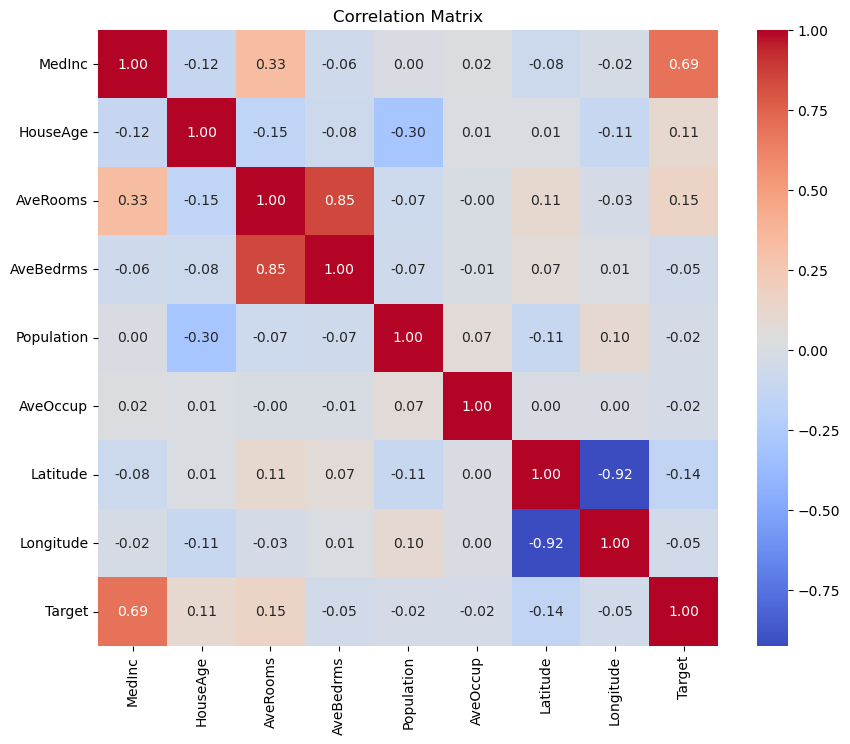

In [6]:
plt.figure(figsize = (10,8))
correlation = df.corr()
sns.heatmap(correlation, annot = True,cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
model = LinearRegression()
X = df.drop("Target", axis=1)
y=df["Target"]
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state=42)
model = LinearRegression()


In [8]:
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
MSE = mean_squared_error(y_test,y_pred)
R2= r2_score(y_test,y_pred)
MAE = mean_absolute_error(y_test,y_pred)
print(f"MSE is {MSE}")
print(f"MAE is {MAE}")
print(f"R2 is {R2}")

MSE is 0.5558915986952443
MAE is 0.5332001304956556
R2 is 0.5757877060324508


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Create the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model on training data
rf_model.fit(X_train, y_train)

# 3. Predict on test data
y_pred_rf = rf_model.predict(X_test)

# 4. Evaluate performance
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("MSE:", mse_rf)
print("MAE:", mae_rf)
print("R2:", r2_rf)


Random Forest Results:
MSE: 0.2553684927247781
MAE: 0.32754256845930246
R2: 0.8051230593157366


In [10]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer

# 1. Feature engineering
df['RoomsPerBedroom'] = df['AveRooms'] / df['AveBedrms'].replace(0, np.nan)
df['PopulationPerHousehold'] = df['Population'] / df['AveOccup'].replace(0, np.nan)
df['MedInc_log'] = np.log1p(df['MedInc'])

# Bin house age safely and fill NaNs
df['HouseAgeGroup'] = pd.cut(df['HouseAge'], bins=[0,10,30,50], labels=[0,1,2])
df['HouseAgeGroup'] = df['HouseAgeGroup'].fillna(0)

# 2. Select features
features = ['MedInc_log','HouseAge','AveRooms','AveBedrms','Population',
            'AveOccup','RoomsPerBedroom','PopulationPerHousehold','HouseAgeGroup']

X = df[features]
y = df['Target']

# 3. Handle NaN or inf values
X.replace([np.inf, -np.inf], np.nan, inplace=True)  # replace inf with NaN
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 4. Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 6. Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 7. Predict
y_pred_lr = lr_model.predict(X_test)

# 8. Evaluate
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression with Feature Engineering (fixed) Results:")
print("MSE:", mse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)


Linear Regression with Feature Engineering (fixed) Results:
MSE: 0.6037005772530186
MAE: 0.5850277270836839
R2: 0.5393036927574857


C:\Users\vivek\AppData\Local\Temp\ipykernel_19900\3010482372.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.replace([np.inf, -np.inf], np.nan, inplace=True)  # replace inf with NaN
